In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, losses

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [2]:
LATENT_DIM   = 100      # Size of the random noise input to Generator
IMG_SHAPE    = (28, 28, 1)
BATCH_SIZE   = 128
EPOCHS       = 50
LR           = 0.0002   # Adam learning rate (DCGAN standard)
BETA_1       = 0.5      # Adam β₁ — lower value stabilises GAN training
SAMPLE_EVERY = 5        # Visualise generated images every N epochs
SAMPLE_ROWS  = 4
SAMPLE_COLS  = 8

# Output folder for saved images
os.makedirs("gan_output", exist_ok=True)
print("Hyperparameters set. Output folder: ./gan_output/")

Hyperparameters set. Output folder: ./gan_output/


Training samples : 60000
Image shape      : (28, 28, 1)
Pixel range      : [-1.0, 1.0]
Batches/epoch    : 468


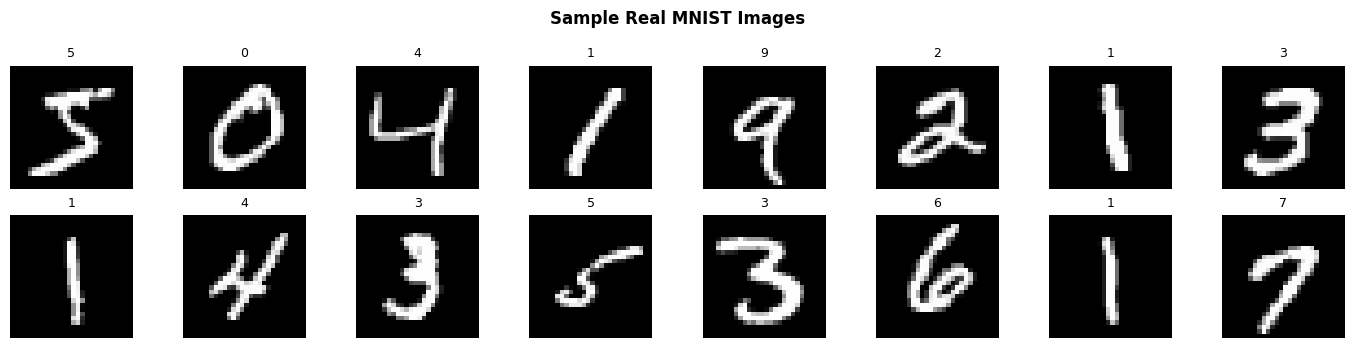

In [3]:
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32")

# Normalize [0, 255] → [-1, 1]
x_train = (x_train - 127.5) / 127.5

# Build tf.data pipeline
dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(buffer_size=60000)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Training samples : {x_train.shape[0]}")
print(f"Image shape      : {x_train.shape[1:]}")
print(f"Pixel range      : [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Batches/epoch    : {len(dataset)}")

fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
fig.suptitle("Sample Real MNIST Images", fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i, :, :, 0], cmap='gray', vmin=-1, vmax=1)
    ax.set_title(str(y_train[i]), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
def build_generator():
    model = tf.keras.Sequential(name="Generator")

    # ── Project noise vector → 7×7 feature maps
    model.add(layers.Dense(7 * 7 * 256, use_bias=False,
                           input_shape=(LATENT_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((7, 7, 256)))                # → (7, 7, 256)

    # ── Block 1: 7×7 → 7×7 ─
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1),
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))                      # → (7, 7, 128)

    # ── Block 2: 7×7 → 14×14 
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))                      # → (14, 14, 64)

    # ── Output: 14×14 → 28×28 
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2),
                                     padding='same', use_bias=False,
                                     activation='tanh'))   # → (28, 28, 1)

    assert model.output_shape == (None, 28, 28, 1), "Generator output shape mismatch!"
    return model


generator = build_generator()
generator.summary()

C:\Users\shafeenausman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12544)               │       1,254,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12544)               │          50,176 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 7, 7, 128)           │         819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 14, 14, 64)          │         204,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 28, 28, 1)           │           1,600 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Generator output shape : (1, 28, 28, 1)
Output value range     : [-0.050, 0.047]


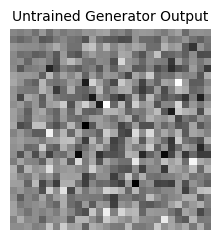

In [5]:
# Quick sanity check — pass random noise through untrained generator
test_noise = tf.random.normal([1, LATENT_DIM])
test_img   = generator(test_noise, training=False)
print(f"Generator output shape : {test_img.shape}")
print(f"Output value range     : [{test_img.numpy().min():.3f}, {test_img.numpy().max():.3f}]")

plt.figure(figsize=(2.5, 2.5))
plt.imshow(test_img[0, :, :, 0], cmap='gray')
plt.title("Untrained Generator Output", fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 5 — Build the Discriminator Network

```
Image (28,28,1) → Conv2D → LeakyReLU → Dropout
               → Conv2D → LeakyReLU → Dropout
               → Flatten → Dense(1) → Sigmoid → p(real)
```

In [6]:
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")

    # ── Block 1: 28×28 → 14×14 ───────────────────────────────────────────────
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=IMG_SHAPE))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))                        # → (14, 14, 64)

    # ── Block 2: 14×14 → 7×7 ─────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))                        # → (7, 7, 128)

    # ── Classifier head ───────────────────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))      # p(real) ∈ (0,1)

    return model


discriminator = build_discriminator()
discriminator.summary()

C:\Users\shafeenausman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 14, 14, 64)          │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 128)           │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           6,273 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

##  Step 6 — Loss Functions & Optimizers

**Loss — Binary Cross-Entropy (BCE):**

| Network | Target labels | Objective |
|---|---|---|
| Discriminator (real) | 1 (real) | Correctly classify real images |
| Discriminator (fake) | 0 (fake) | Correctly classify fake images |
| Generator | 1 (fool D) | Make D believe fakes are real |

In [7]:
# ── Loss function ─────────────────────────────────────────────────────────────
cross_entropy = losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    """D should output 1 for real, 0 for fake."""
    real_loss = cross_entropy(tf.ones_like(real_output),  real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    """G wins when D outputs 1 (real) for fake images."""
    return cross_entropy(tf.ones_like(fake_output), fake_output)


# ── Optimizers (Adam, lr=0.0002, β₁=0.5) ─────────────────────────────────────
gen_optimizer  = optimizers.Adam(learning_rate=LR, beta_1=BETA_1)
disc_optimizer = optimizers.Adam(learning_rate=LR, beta_1=BETA_1)

print("Loss functions and optimizers ready.")

Loss functions and optimizers ready.


##  Step 7 — Training Step (Single Batch)

Both networks are updated **alternately** in each step:
1. Forward pass → compute D loss → update D weights
2. Forward pass → compute G loss → update G weights

`@tf.function` compiles the function into a TF graph for ~3× faster execution.

In [8]:
@tf.function
def train_step(real_images):
    # Sample random noise
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # G: noise → fake images
        fake_images = generator(noise, training=True)

        # D: classify both real and fake
        real_output = discriminator(real_images,  training=True)
        fake_output = discriminator(fake_images,  training=True)

        # Compute losses
        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    # Compute & apply gradients
    g_grads = gen_tape.gradient(g_loss,  generator.trainable_variables)
    d_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients( zip(g_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    return g_loss, d_loss


print("train_step() compiled and ready.")

train_step() compiled and ready.


## Step 8 — Image Grid Visualization Helper

A **fixed noise seed** is reused every time so we can track visual progress consistently.

Untrained generator output (pure noise):


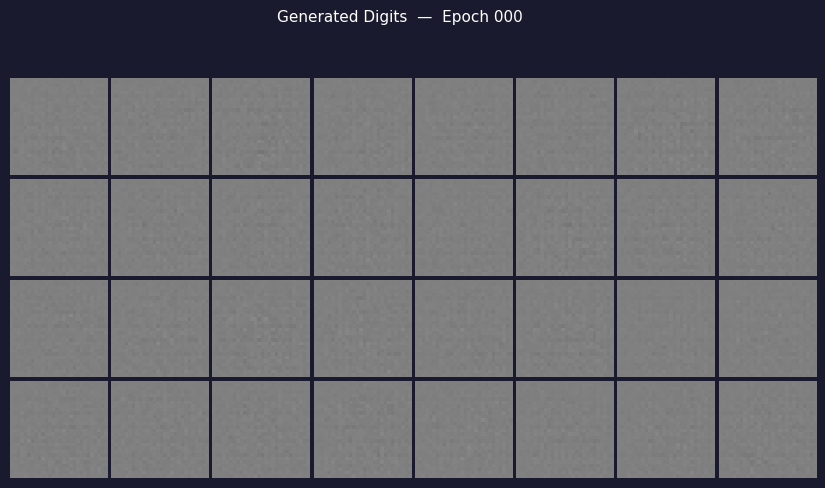

In [9]:
# Fixed seed for consistent progress tracking
fixed_noise = tf.random.normal([SAMPLE_ROWS * SAMPLE_COLS, LATENT_DIM])

def show_and_save_grid(epoch, save=True):
    """Generate images from fixed noise and display a grid."""
    generated = generator(fixed_noise, training=False).numpy()
    generated = (generated + 1.0) / 2.0  # rescale [-1,1] → [0,1]

    fig = plt.figure(figsize=(SAMPLE_COLS * 1.3, SAMPLE_ROWS * 1.3))
    fig.patch.set_facecolor('#1a1a2e')
    gs  = gridspec.GridSpec(SAMPLE_ROWS, SAMPLE_COLS, wspace=0.04, hspace=0.04)

    for i in range(SAMPLE_ROWS * SAMPLE_COLS):
        ax = fig.add_subplot(gs[i // SAMPLE_COLS, i % SAMPLE_COLS])
        ax.imshow(generated[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

    plt.suptitle(f'Generated Digits  —  Epoch {epoch:03d}',
                 color='white', fontsize=11, y=1.01)
    if save:
        path = f"gan_output/epoch_{epoch:03d}.png"
        plt.savefig(path, bbox_inches='tight', dpi=120,
                    facecolor=fig.get_facecolor())
    plt.show()
    plt.close()


# Preview with untrained generator
print("Untrained generator output (pure noise):")
show_and_save_grid(epoch=0, save=False)

##  Step 9 — Full Training Loop

>  **Expected runtime:** ~3 min/epoch on CPU, ~15 sec/epoch on GPU  
> For a quick test, set `EPOCHS = 5` above.

  GAN Training Started
  Epochs: 50  |  Batch: 128  |  LR: 0.0002
Epoch [  1/50]  D Loss: 1.3068   G Loss: 0.7173   (193.3s)


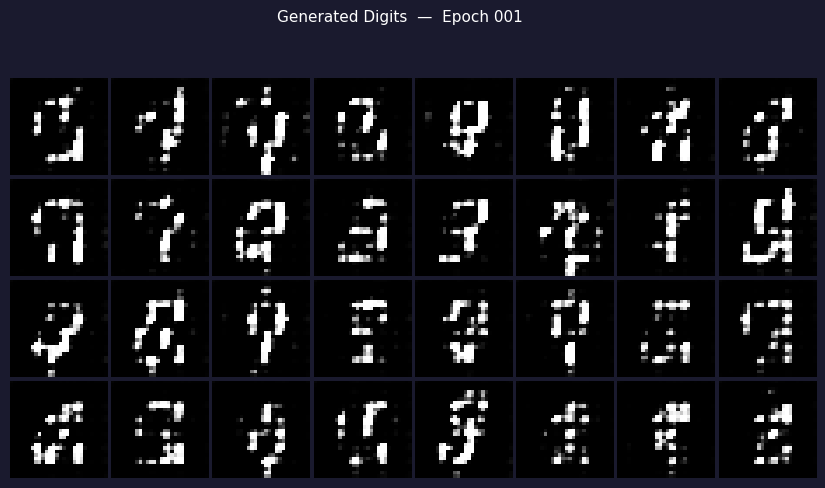

Epoch [  2/50]  D Loss: 1.3002   G Loss: 0.7868   (205.4s)
Epoch [  3/50]  D Loss: 1.2676   G Loss: 0.8307   (228.4s)
Epoch [  4/50]  D Loss: 1.3137   G Loss: 0.7904   (198.8s)
Epoch [  5/50]  D Loss: 1.3270   G Loss: 0.7712   (374.2s)


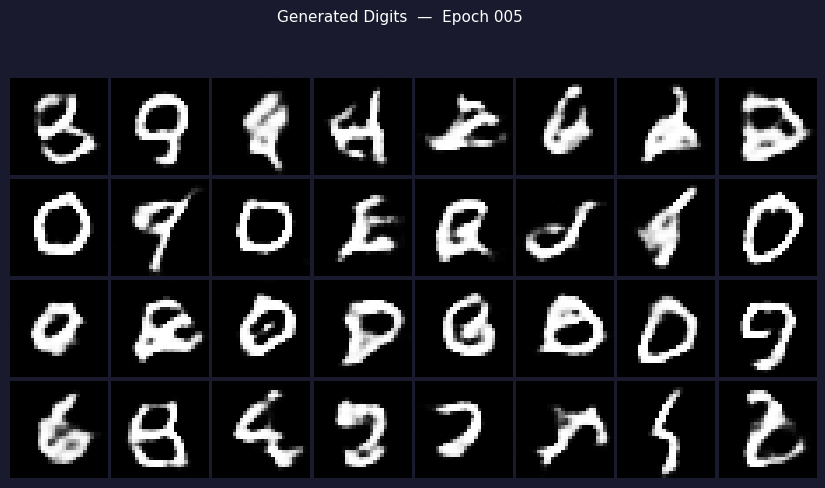

Epoch [  6/50]  D Loss: 1.3219   G Loss: 0.7720   (245.3s)
Epoch [  7/50]  D Loss: 1.3145   G Loss: 0.7811   (304.9s)
Epoch [  8/50]  D Loss: 1.3082   G Loss: 0.7876   (538.5s)
Epoch [  9/50]  D Loss: 1.3012   G Loss: 0.7965   (258.7s)
Epoch [ 10/50]  D Loss: 1.2922   G Loss: 0.8095   (261.0s)


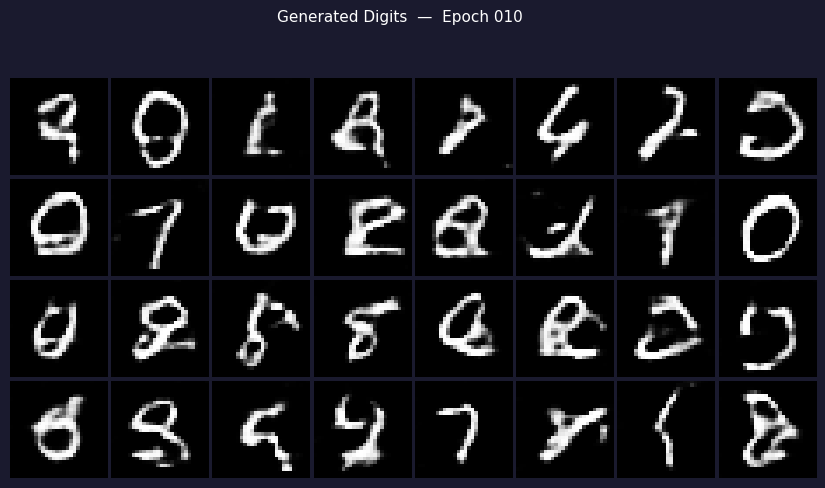

Epoch [ 11/50]  D Loss: 1.2924   G Loss: 0.8122   (270.5s)
Epoch [ 12/50]  D Loss: 1.2871   G Loss: 0.8159   (256.6s)
Epoch [ 13/50]  D Loss: 1.2877   G Loss: 0.8245   (269.1s)
Epoch [ 14/50]  D Loss: 1.2865   G Loss: 0.8161   (296.0s)
Epoch [ 15/50]  D Loss: 1.2865   G Loss: 0.8273   (315.7s)


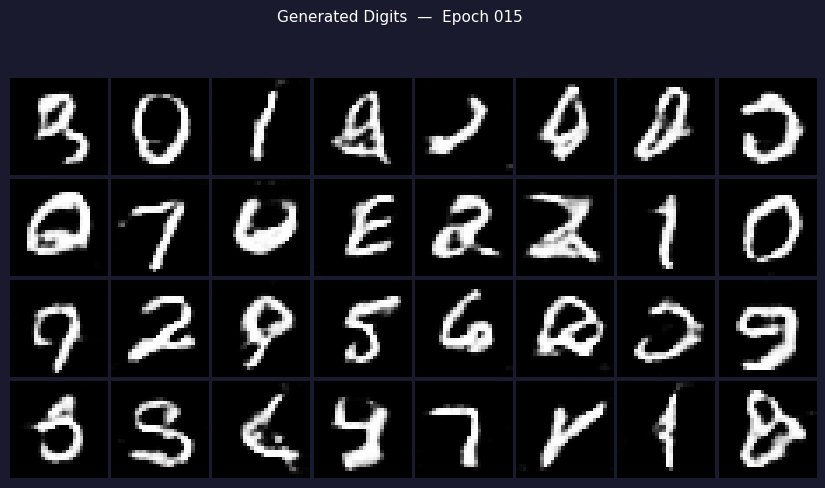

Epoch [ 16/50]  D Loss: 1.2873   G Loss: 0.8231   (205.1s)
Epoch [ 17/50]  D Loss: 1.2902   G Loss: 0.8269   (200.0s)
Epoch [ 18/50]  D Loss: 1.2872   G Loss: 0.8225   (195.8s)
Epoch [ 19/50]  D Loss: 1.2925   G Loss: 0.8297   (189.7s)
Epoch [ 20/50]  D Loss: 1.2940   G Loss: 0.8187   (190.0s)


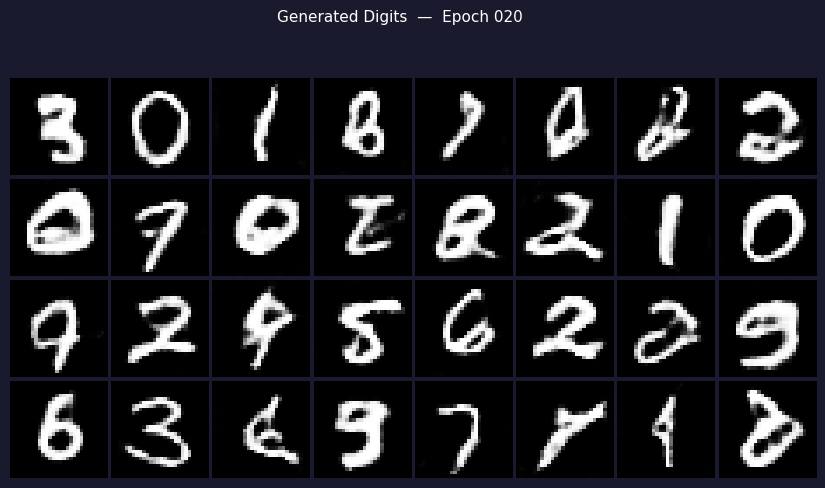

Epoch [ 21/50]  D Loss: 1.2996   G Loss: 0.8090   (188.4s)
Epoch [ 22/50]  D Loss: 1.2949   G Loss: 0.8330   (189.1s)
Epoch [ 23/50]  D Loss: 1.2993   G Loss: 0.8070   (203.9s)
Epoch [ 24/50]  D Loss: 1.2981   G Loss: 0.8225   (189.9s)
Epoch [ 25/50]  D Loss: 1.3051   G Loss: 0.8049   (188.0s)


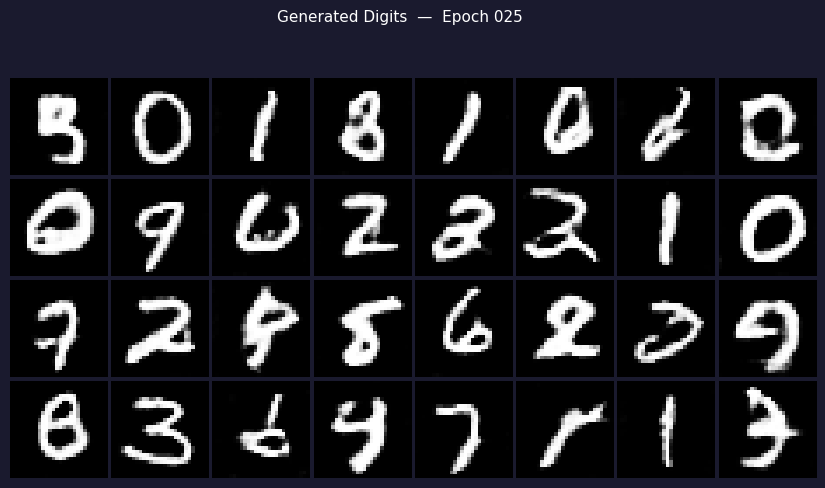

Epoch [ 26/50]  D Loss: 1.3018   G Loss: 0.8245   (195.9s)
Epoch [ 27/50]  D Loss: 1.3056   G Loss: 0.8009   (187.9s)
Epoch [ 28/50]  D Loss: 1.3004   G Loss: 0.8197   (193.6s)
Epoch [ 29/50]  D Loss: 1.3082   G Loss: 0.8015   (528.1s)
Epoch [ 30/50]  D Loss: 1.3041   G Loss: 0.8133   (197.8s)


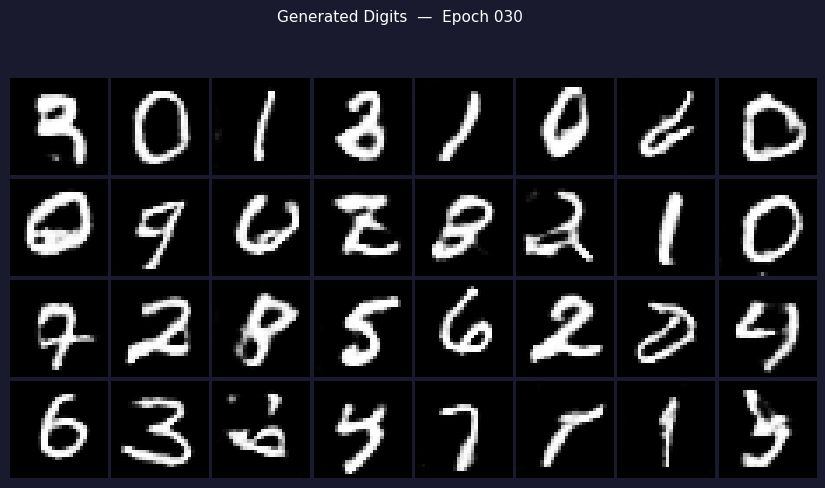

Epoch [ 31/50]  D Loss: 1.3104   G Loss: 0.8043   (237.7s)
Epoch [ 32/50]  D Loss: 1.3037   G Loss: 0.8154   (191.1s)
Epoch [ 33/50]  D Loss: 1.3082   G Loss: 0.8015   (211.0s)
Epoch [ 34/50]  D Loss: 1.3060   G Loss: 0.8116   (268.4s)
Epoch [ 35/50]  D Loss: 1.3092   G Loss: 0.8075   (250.6s)


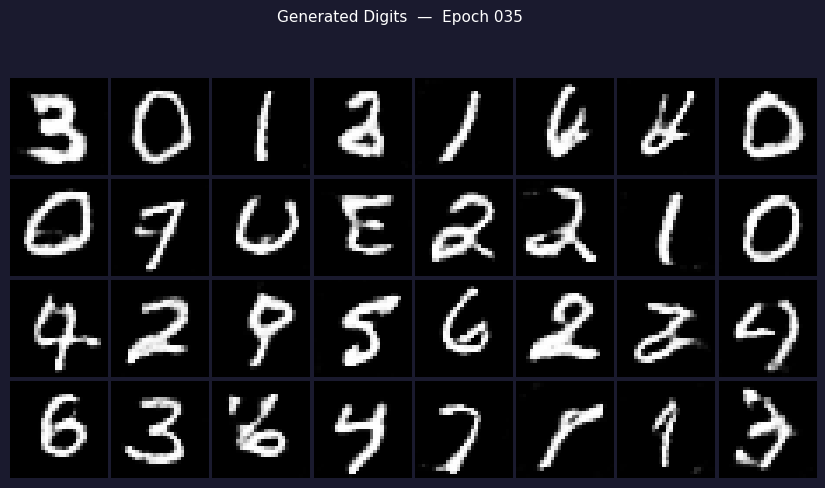

Epoch [ 36/50]  D Loss: 1.3100   G Loss: 0.8032   (235.6s)
Epoch [ 37/50]  D Loss: 1.3064   G Loss: 0.8095   (189.0s)
Epoch [ 38/50]  D Loss: 1.3083   G Loss: 0.8054   (184.4s)
Epoch [ 39/50]  D Loss: 1.3058   G Loss: 0.8127   (179.1s)
Epoch [ 40/50]  D Loss: 1.3108   G Loss: 0.8025   (177.6s)


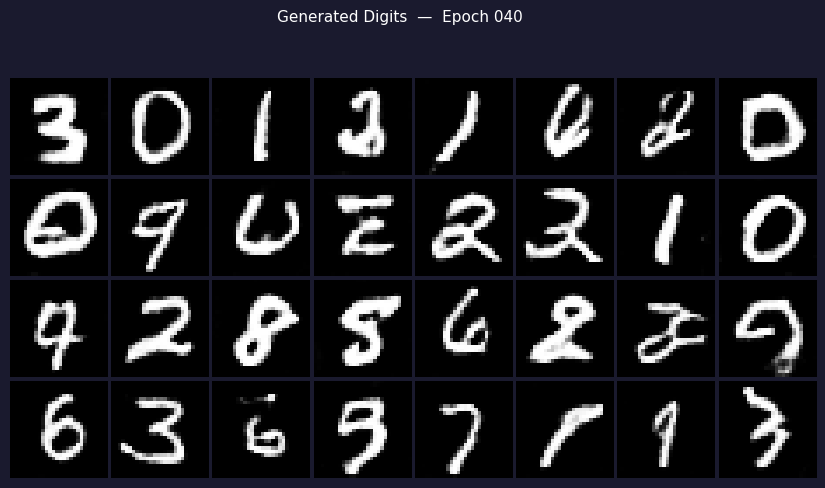

Epoch [ 41/50]  D Loss: 1.3127   G Loss: 0.8045   (178.6s)
Epoch [ 42/50]  D Loss: 1.3072   G Loss: 0.8057   (187.7s)
Epoch [ 43/50]  D Loss: 1.3049   G Loss: 0.8131   (23051.2s)
Epoch [ 44/50]  D Loss: 1.3074   G Loss: 0.8074   (213.8s)
Epoch [ 45/50]  D Loss: 1.3076   G Loss: 0.8090   (199.0s)


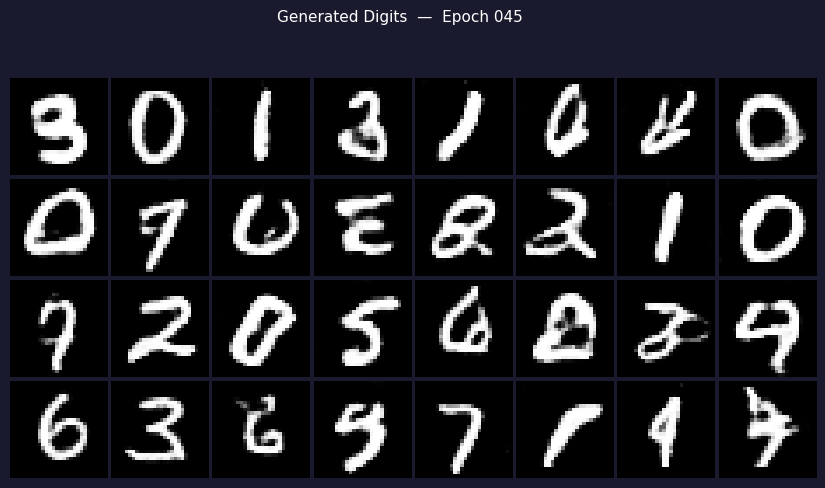

Epoch [ 46/50]  D Loss: 1.3055   G Loss: 0.8111   (187.3s)
Epoch [ 47/50]  D Loss: 1.3060   G Loss: 0.8154   (176.6s)
Epoch [ 48/50]  D Loss: 1.3073   G Loss: 0.8066   (181.4s)
Epoch [ 49/50]  D Loss: 1.3054   G Loss: 0.8137   (181.0s)
Epoch [ 50/50]  D Loss: 1.3060   G Loss: 0.8148   (179.6s)


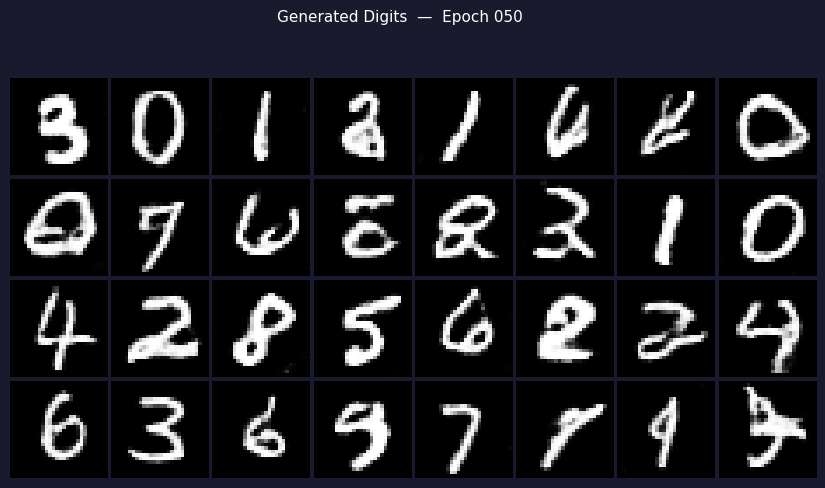

  Training complete in 572.4 min


In [10]:
g_losses, d_losses = [], []

print("=" * 60)
print("  GAN Training Started")
print(f"  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LR}")
print("=" * 60)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    epoch_g, epoch_d = [], []

    for real_batch in dataset:
        g_loss, d_loss = train_step(real_batch)
        epoch_g.append(float(g_loss))
        epoch_d.append(float(d_loss))

    mean_g = np.mean(epoch_g)
    mean_d = np.mean(epoch_d)
    g_losses.append(mean_g)
    d_losses.append(mean_d)
    elapsed = time.time() - epoch_start

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"D Loss: {mean_d:.4f}   G Loss: {mean_g:.4f}   "
          f"({elapsed:.1f}s)")

    # Visualise and save grid every SAMPLE_EVERY epochs (and epoch 1)
    if epoch % SAMPLE_EVERY == 0 or epoch == 1:
        show_and_save_grid(epoch)

total_time = time.time() - total_start
print("=" * 60)
print(f"  Training complete in {total_time/60:.1f} min")
print("=" * 60)

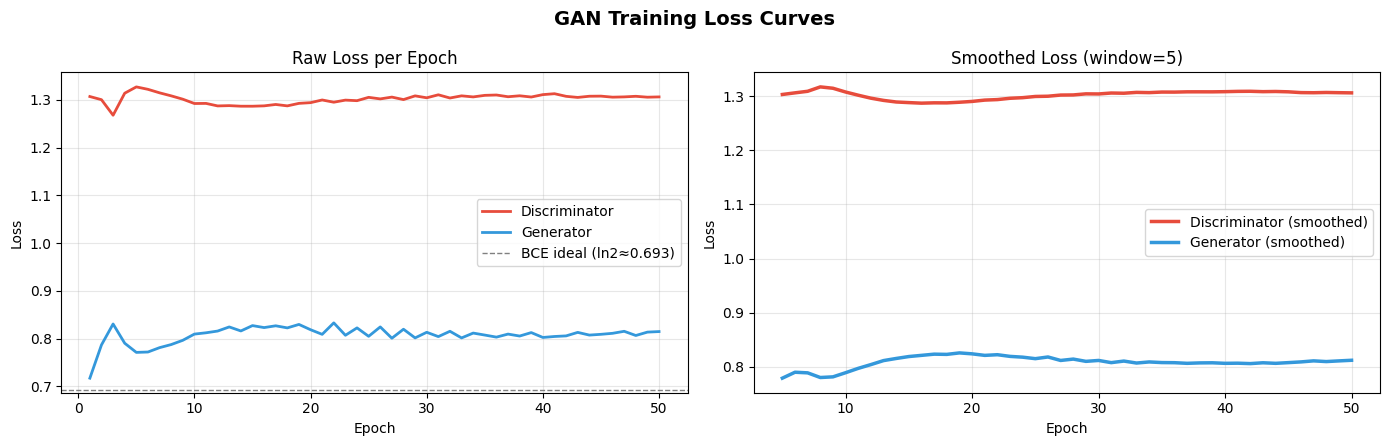

Loss curves saved → gan_output/loss_curves.png


In [11]:
def smooth(y, w=5):
    return np.convolve(y, np.ones(w) / w, mode='valid')

epochs_axis = range(1, len(g_losses) + 1)
sw = 5
se = range(sw, len(g_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('GAN Training Loss Curves', fontsize=14, fontweight='bold')

# Left — raw losses
ax = axes[0]
ax.plot(epochs_axis, d_losses, color='#e74c3c', lw=2, label='Discriminator')
ax.plot(epochs_axis, g_losses, color='#3498db', lw=2, label='Generator')
ax.axhline(y=0.693, color='gray', lw=1, linestyle='--', label='BCE ideal (ln2≈0.693)')
ax.set_title('Raw Loss per Epoch', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Right — smoothed losses
ax2 = axes[1]
ax2.plot(se, smooth(d_losses, sw), color='#e74c3c', lw=2.5, label='Discriminator (smoothed)')
ax2.plot(se, smooth(g_losses, sw), color='#3498db', lw=2.5, label='Generator (smoothed)')
ax2.set_title(f'Smoothed Loss (window={sw})', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gan_output/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curves saved → gan_output/loss_curves.png")

Final generated digit grid after training:


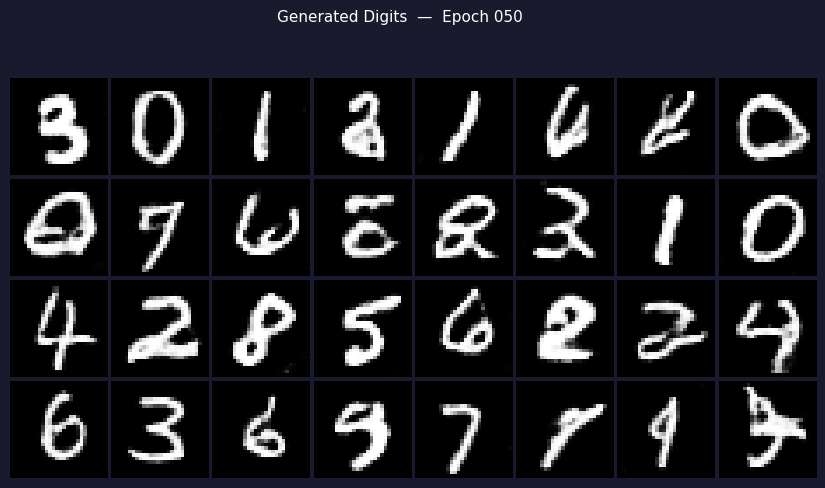

In [12]:
print("Final generated digit grid after training:")
show_and_save_grid(epoch=EPOCHS)

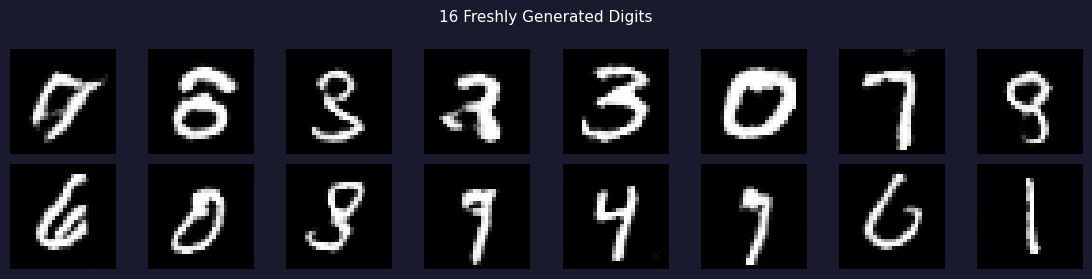

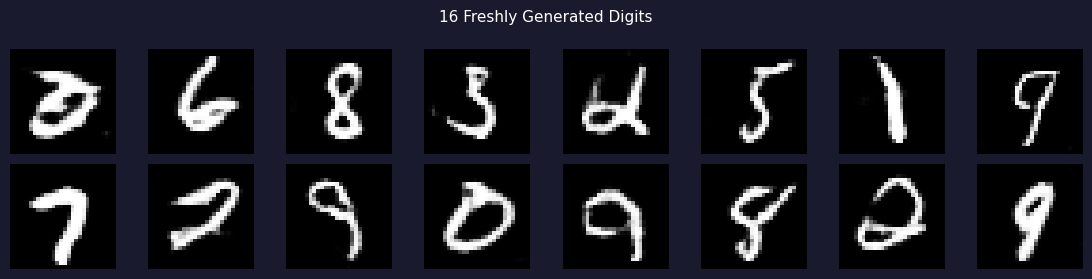

In [13]:
def generate_new_samples(n=16, seed=None):
    """Generate a fresh batch of digits with a new random seed."""
    if seed is not None:
        tf.random.set_seed(seed)
    noise = tf.random.normal([n, LATENT_DIM])
    imgs  = generator(noise, training=False).numpy()
    imgs  = (imgs + 1.0) / 2.0

    cols = min(n, 8)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
    fig.patch.set_facecolor('#1a1a2e')
    axes = np.array(axes).flat
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(imgs[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.suptitle(f'{n} Freshly Generated Digits', color='white', fontsize=11)
    plt.tight_layout()
    plt.show()

# Run with different seeds to see variety
generate_new_samples(n=16, seed=101)
generate_new_samples(n=16, seed=202)

In [14]:

generator.save('gan_output/generator.keras')
discriminator.save('gan_output/discriminator.keras')
print("Models saved to ./gan_output/")
print("  generator.keras")
print("  discriminator.keras")

Models saved to ./gan_output/
  generator.keras
  discriminator.keras
